In [8]:
import streamlit as st
import pandas as pd


This is the dataset, 2 of them, I would like to know, what factor affects the delivery time the most? 

1 of all, IDA, scan through the document and see if there is any missing values. drop them for now.

In [7]:
%matplotlib inline
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
nyc = pd.read_csv("NYC_food_order.csv",na_values=['Not given'])
fdt = pd.read_csv("Food_Delivery_Times.csv")

In [4]:
row6 = nyc.iloc[:, 6]
print(row6)
allnumberrow6 = row6.dropna()

0       NaN
1       NaN
2       5.0
3       3.0
4       4.0
       ... 
1893    5.0
1894    5.0
1895    NaN
1896    5.0
1897    NaN
Name: rating, Length: 1898, dtype: float64


still, very low correlation. it does seem that the restaurants delivery time has nothing to do with type of restaurant.

now, we try no. 2: Impututation. What if we impute some data, and then will there be correlation? 

Fist, let's decide if the missing value is MAR, MCAR or MNAR.

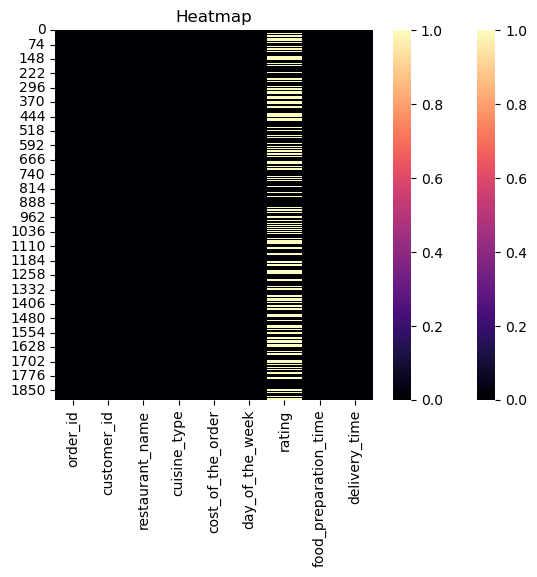

In [63]:
sns.heatmap(nyc.isna(), cmap="magma")
plt.title("Heatmap")
plt.show()

this is a Univariate missing, I need to now determine if it is MNAR,MAR or MCAR.

In [6]:
nyc["was_NaN"] = False
nyc.loc[nyc["rating"].isnull() == True, "was_NaN"] = True
nyc.head(8)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,was_NaN
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,True
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,True
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,False
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,False
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,False
5,1477224,147468,Tamarind TriBeCa,Indian,25.22,Weekday,3.0,20,24,False
6,1477894,157711,The Meatball Shop,Italian,6.07,Weekend,NaN,28,21,True
7,1477859,89574,Barbounia,Mediterranean,5.97,Weekday,3.0,33,30,False


In [7]:
sns.pairplot(nyc, hue="was_NaN")

this is definitely MCAR.

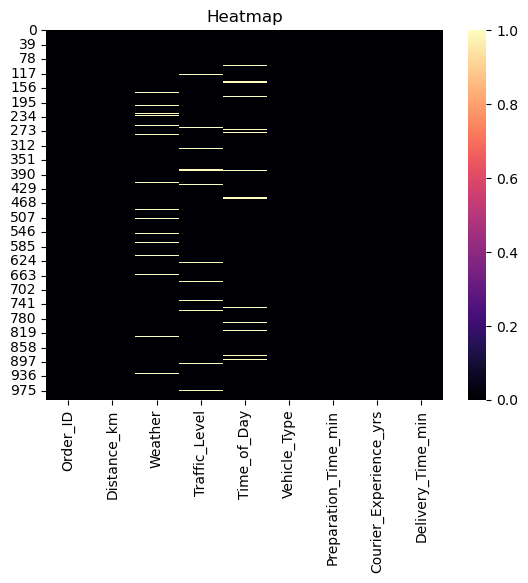

In [75]:
sns.heatmap(fdt.isna(), cmap="magma")
plt.title("Heatmap")
plt.show()


数值列列表: ['cost_of_the_order', 'rating', 'food_preparation_time', 'delivery_time']

KNN填充后评分列缺失值数量: 0


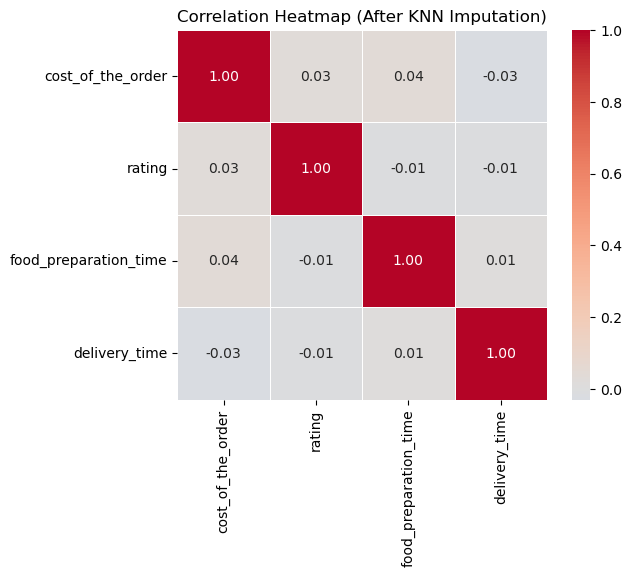

In [55]:
from sklearn.impute import KNNImputer
numeric_cols = nyc.select_dtypes(include=['number']).columns.tolist()
print("\n数值列列表:", numeric_cols)

imputer = KNNImputer(n_neighbors=5)

nyc[numeric_cols] = imputer.fit_transform(nyc[numeric_cols])

print(f"\nKNN填充后评分列缺失值数量: {nyc['rating'].isna().sum()}")

correlation_matrix = nyc[numeric_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap (After KNN Imputation)', fontsize=12)
plt.show()

After imputation, it seems still has no correlation at all with ratings! 

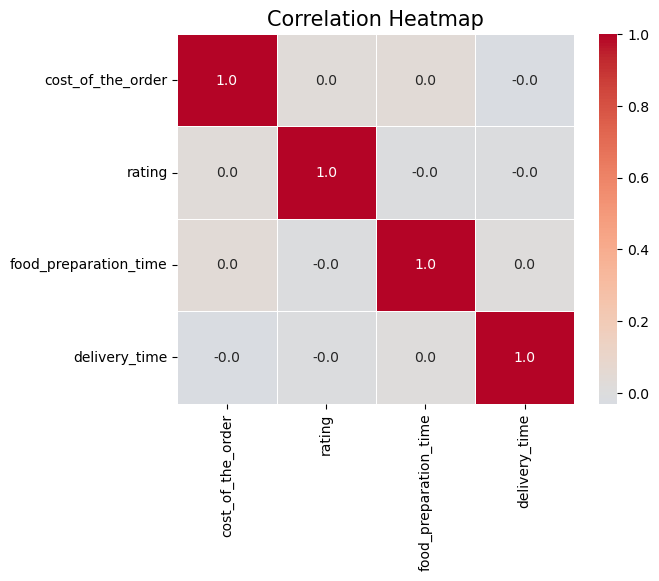

In [56]:
nyc = nyc.drop(nyc.columns[:2], axis=1)
numeric_df = nyc.select_dtypes(include='number')
nyc_correlation = numeric_df.corr()
sns.heatmap(
    nyc_correlation,
    annot=True,          # 在热图上显示相关系数值
    cmap='coolwarm',     # 颜色主题
    center=0,            # 颜色中心值
    fmt='.1f',           # 数值格式（保留两位小数）
    linewidths=0.5       # 格子线宽度
)
plt.title('Correlation Heatmap', fontsize=15)
plt.show()

In [10]:
print(nyc.info())
print(numeric_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   restaurant_name        1898 non-null   object 
 1   cuisine_type           1898 non-null   object 
 2   cost_of_the_order      1898 non-null   float64
 3   day_of_the_week        1898 non-null   object 
 4   rating                 1898 non-null   float64
 5   food_preparation_time  1898 non-null   float64
 6   delivery_time          1898 non-null   float64
 7   was_NaN                1898 non-null   bool   
dtypes: bool(1), float64(4), object(3)
memory usage: 105.8+ KB
None
   cost_of_the_order  rating  food_preparation_time  delivery_time
0              30.75     3.8                   25.0           20.0
1              12.08     4.2                   25.0           23.0
2              12.23     5.0                   23.0           28.0
3              29.20     3.0          

wow, this is shocking. not a single bit of correlation. Now, we need to do a bit further analysis. I did not take into consideration the difference between the weekday and weekends, I need to separate that first. 

In [11]:
weekday_nyc = nyc[nyc['day_of_the_week'] == 'Weekday']
weekend_nyc = nyc[nyc['day_of_the_week'] == 'Weekend']
numeric_columns = nyc.select_dtypes(include=['number']).columns.tolist()
weekday_numeric = weekday_nyc[numeric_columns]
weekend_numeric = weekend_nyc[numeric_columns]

In [12]:
weekday_corr = weekday_numeric.corr()
sns.heatmap(weekday_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Weekday Correlation Heatmap')

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Text(0.5, 1.0, 'Weekday Correlation Heatmap')

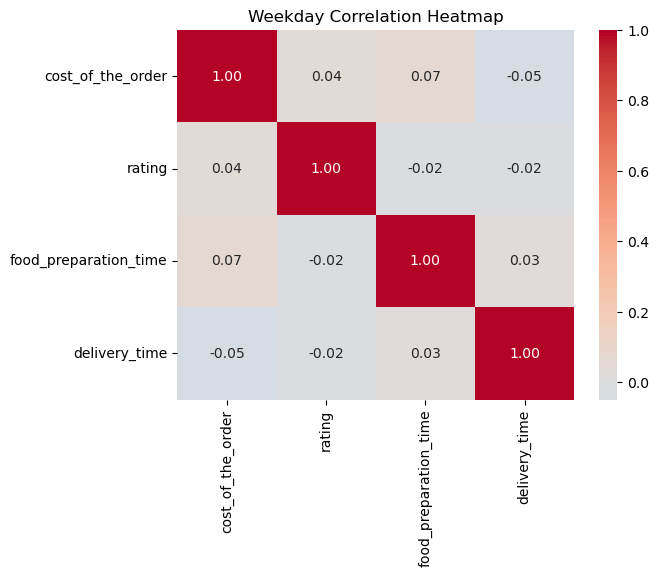

In [65]:
weekend_corr = weekend_numeric.corr()
sns.heatmap(weekend_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Weekday Correlation Heatmap')
plt.show()

so now, it finally shows some correlation. However, it is still too weak, there is only a little correlation between the rating of the restaurant vs the delivery time during weekdays, but even that is still weak.

Now, we are going to separate the dish categories and do another correlation map. 

In [14]:
eastern_cuisines = ['Chinese', 'Korean', 'Japanese', 'Indian', 'Thai']
eastern = nyc[nyc['cuisine_type'].isin(eastern_cuisines)]

western_cuisines = ['Italian', 'American', 'Mediterranean', 'Middle Eastern', 'Mexican', 'Southern', 'French', 'Spanish']
western = nyc[nyc['cuisine_type'].isin(western_cuisines)]

numeric_columns = nyc.select_dtypes(include=['number']).columns.tolist()

eastern_numeric = eastern[numeric_columns]
western_numeric = western[numeric_columns]

In [15]:
eastern_corr = eastern_numeric.corr()
sns.heatmap(eastern_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Eastern Cuisine Correlation Heatmap')

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Text(0.5, 1.0, 'Eastern Cuisine Correlation Heatmap')

In [16]:
western_corr = western_numeric.corr()
sns.heatmap(western_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Western Cuisine Correlation Heatmap')

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Text(0.5, 1.0, 'Western Cuisine Correlation Heatmap')

Next, we are going to do the same with another dataset: Food_delivery_time, see if we have the same result.

In [17]:
fdt = pd.read_csv("Food_Delivery_Times.csv")

In [18]:
fdt.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [19]:
sns.heatmap(fdt.isna(), cmap="magma")
plt.title("Heatmap")

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Text(0.5, 1.0, 'Heatmap')

after examining the missing values, I found that there is little missing values for this dataset, therefore no need for any imputation here

In [20]:
numeric_fdt = fdt.select_dtypes(include='number')
fdt_correlation = numeric_fdt.corr()
sns.heatmap(
    fdt_correlation,
    annot=True,          # 在热图上显示相关系数值
    cmap='coolwarm',     # 颜色主题
    center=0,            # 颜色中心值
    fmt='.2f',           # 数值格式（保留两位小数）
    linewidths=0.5       # 格子线宽度
)
plt.title('Correlation Heatmap', fontsize=15)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Text(0.5, 1.0, 'Correlation Heatmap')

In [21]:
fdt["was_NaN"] = False
fdt.loc[nyc["rating"].isnull() == True, "was_NaN"] = True
fdt.head(8)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,was_NaN
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,False
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,False
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,False
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,False
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,False
5,679,19.40,Clear,Low,Evening,Scooter,8,9.0,57,False
6,627,9.52,Clear,Low,NaN,Bike,12,1.0,49,False
7,514,17.39,Clear,Medium,Evening,Scooter,5,6.0,46,False


In [22]:
sns.pairplot(fdt, hue="was_NaN")


数值列列表: ['cost_of_the_order', 'rating', 'food_preparation_time', 'delivery_time']

KNN填充后评分列缺失值数量: 0


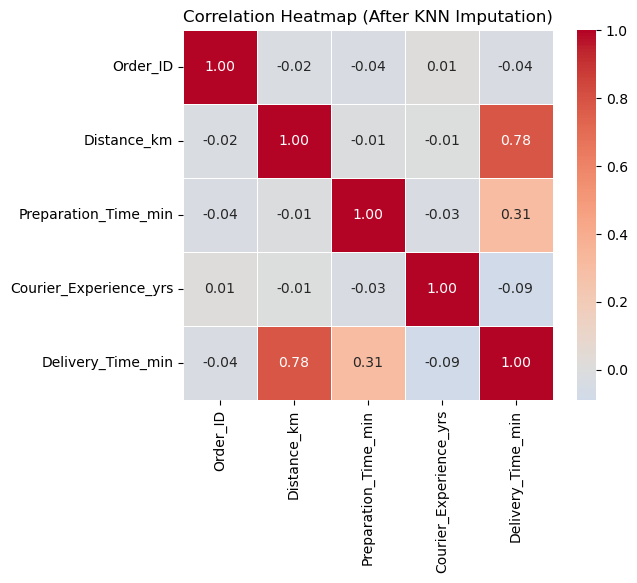

In [64]:
from sklearn.impute import KNNImputer
numeric_colsfdt = fdt.select_dtypes(include=['number']).columns.tolist()
print("\n数值列列表:", numeric_cols)

imputer = KNNImputer(n_neighbors=5)

fdt[numeric_colsfdt] = imputer.fit_transform(fdt[numeric_colsfdt])

print(f"\nKNN填充后评分列缺失值数量: {fdt['Courier_Experience_yrs'].isna().sum()}")

correlation_matrixfdt = fdt[numeric_colsfdt].corr()

sns.heatmap(
    correlation_matrixfdt,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=0.5
)

plt.title('Correlation Heatmap (After KNN Imputation)', fontsize=12)
plt.show()

imputation does not matter here, the only thing that matters the most is the distance in km, and has something to do with the preparation time too. 

next thing, gonna separate the categorical stats, see their interaction with the delivery time now.

In [24]:
categorical_cols = ['Time_of_Day', 'Vehicle_Type',"Traffic_Level","Weather"]
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='Delivery_Time_min', data=fdt)
    plt.title(f'Delivery Time vs {col}')
    plt.xticks(rotation=45)  # 防止标签重叠
    #plt.show()

now, we will do some EDA. It does seem that the only thing that is strongly correlated to delivery time is distance, therefore, we will do some analysis on distance and time.

In [25]:
from scipy.stats import pearsonr

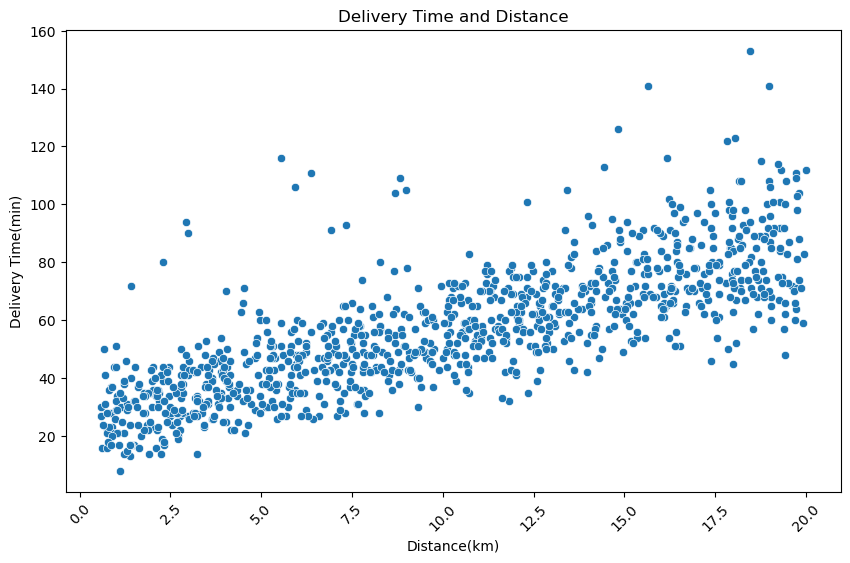

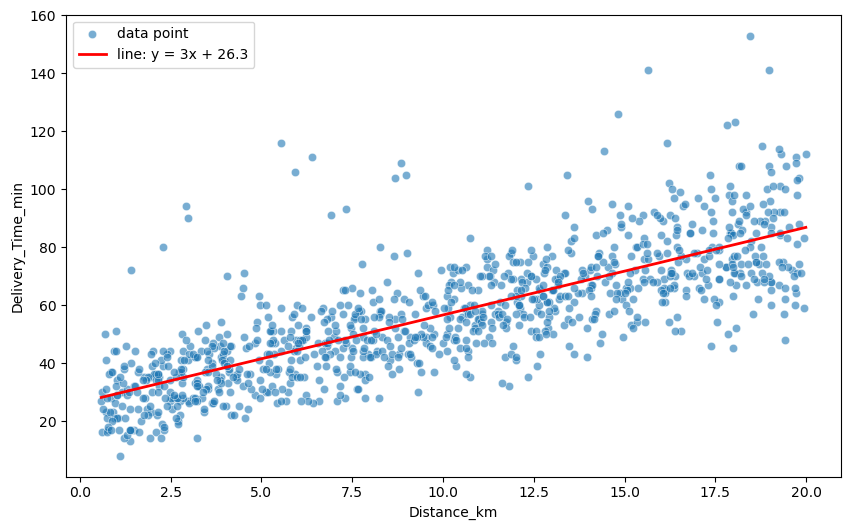

In [74]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=fdt, x='Distance_km', y='Delivery_Time_min')
plt.title('Delivery Time and Distance')
plt.xlabel('Distance(km)')
plt.xticks(rotation=45)
plt.ylabel('Delivery Time(min)')
plt.show()

correlation, p_value = pearsonr(fdt['Distance_km'], fdt['Delivery_Time_min'])

from scipy.optimize import curve_fit

def linear_func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(linear_func, fdt['Distance_km'], fdt['Delivery_Time_min'])
a, b = popt

plt.figure(figsize=(10, 6))
sns.scatterplot(data=fdt, x='Distance_km', y='Delivery_Time_min', alpha=0.6, label='data point')

x_range = np.linspace(fdt['Distance_km'].min(), fdt['Distance_km'].max(), 100)
y_fit = linear_func(x_range, a, b)

plt.plot(x_range, y_fit, 'r-', linewidth=2, label='line: y = 3x + 26.3')
plt.legend()
plt.show()

In [27]:
print(f'Pearson correlation between Distance and Delivery Time：{correlation:.2f}，p Value：{p_value:.2f}')

Pearson correlation between Distance and Delivery Time：0.78，p Value：0.00


In [28]:
fdt['distance_bin'] = pd.cut(fdt['Distance_km'], bins=range(0, int(fdt['Distance_km'].max()) + 5, 5))

bin_stats = fdt.groupby('distance_bin')['Delivery_Time_min'].agg(['mean', 'median','std']).reset_index()

print(bin_stats)

  distance_bin       mean  median        std
0       (0, 5]  34.326613    34.0  12.515018
1      (5, 10]  49.029046    48.0  14.809737
2     (10, 15]  63.361538    63.0  13.348610
3     (15, 20]  79.398406    77.0  16.731307


C:\Users\USER\AppData\Local\Temp\ipykernel_30456\1308957675.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = fdt.groupby('distance_bin')['Delivery_Time_min'].agg(['mean', 'median','std']).reset_index()


## End of Semester Project

Finally! We are going to the final sem part. we will bring over a brand new dataset and also do analysis on it as well. 

In [4]:
ifd = pd.read_csv('India_Food_Delivery.csv')
ifd= ifd.replace(
    ['NaN ', 'nan', 'NAN', 'Nan', None, '', ' '], 
    np.nan
)

In [32]:
ifd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          43739 non-null  object 
 3   Delivery_person_Ratings      43685 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  43862 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weather                      45593 non-null  object 
 12  Road_traffic_density         44992 non-null  object 
 13  Vehicle_conditio

**Some rows have NaNs and are not shown above, need to use computational method to make them shown!**

In [6]:
cols_to_replace = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude']

In [7]:
ifd[cols_to_replace] = ifd[cols_to_replace].replace(0, np.nan)

In [8]:
complete_rows = ifd.dropna().shape[0]
print(f"No NaN rows: {complete_rows}")

No NaN rows: 38064


In [9]:
print(ifd.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude            3640
Restaurant_longitude           3640
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64


In [10]:
ifd.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19 03 2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25 03 2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19 03 2022,8:30:00,8:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,5 04 2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26 03 2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,30


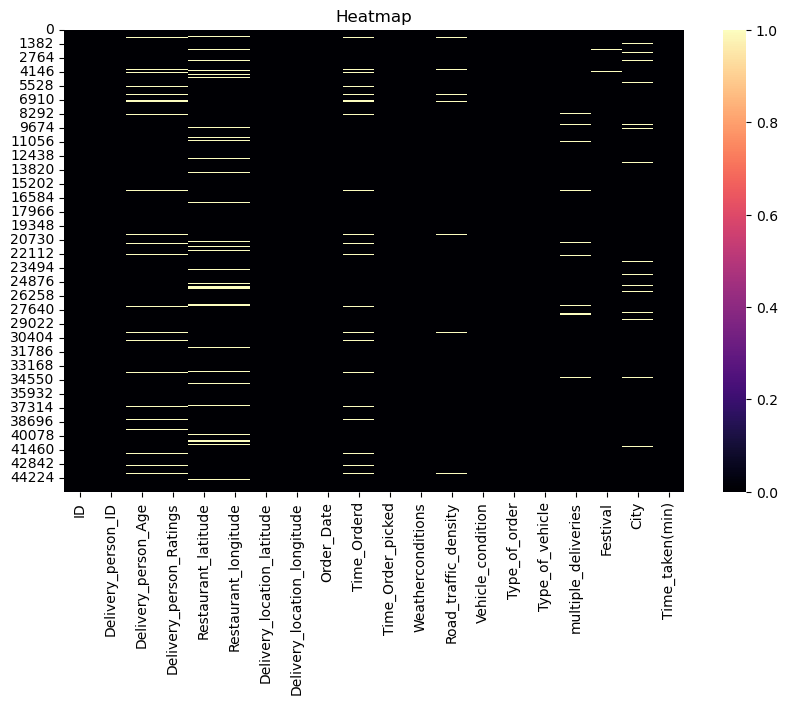

In [11]:
sns.heatmap(ifd.isna(), cmap="magma")
plt.title("Heatmap")
plt.show()

**Since there is more than enough data we can work on, we will just drop all of the missing value lanes.**

In [5]:
ifd = ifd.dropna()

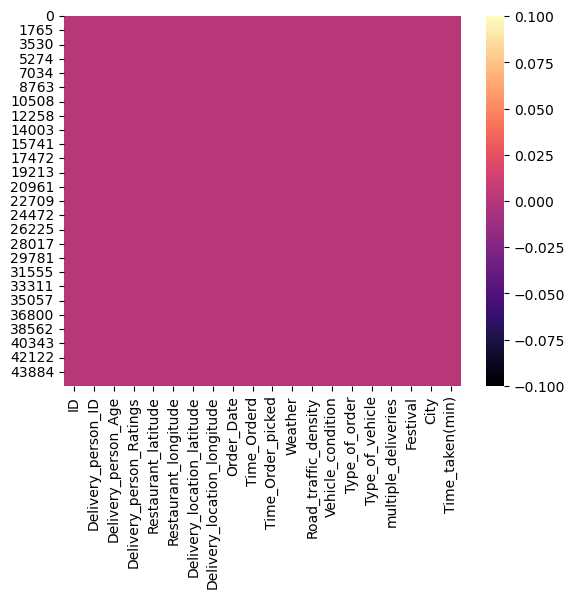

In [9]:
## after dropping all the missing value columns 
sns.heatmap(ifd.isna(), cmap="magma")
plt.show()

Now we will do some analysis on this dataset. First, need to calculate distance with the given values of longitude and latitude values. 

In [81]:
!pip install geopy

In [82]:
from geopy.distance import geodesic

In [110]:
def calculate_distance(row):
    restaurant = (row['Restaurant_latitude'], row['Restaurant_longitude'])
    delivery = (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
    return geodesic(restaurant, delivery).kilometers

ifd['distance_km'] = ifd.apply(calculate_distance, axis=1)

print(ifd[['Restaurant_latitude', 'Restaurant_longitude', 
           'Delivery_location_latitude', 'Delivery_location_longitude', 
           'distance_km']].head(15))

    Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0             22.745049             75.892471                   22.765049   
1             12.913041             77.683237                   13.043041   
2             12.914264             77.678400                   12.924264   
3             11.003669             76.976494                   11.053669   
4             12.972793             80.249982                   13.012793   
5             17.431668             78.408321                   17.461668   
6             23.369746             85.339820                   23.479746   
7             12.352058             76.606650                   12.482058   
8             17.433809             78.386744                   17.563809   
9             30.327968             78.046106                   30.397968   
10            10.003064             76.307589                   10.043064   
11            18.562450             73.916619                   18.652450   

In [111]:
ifddistance = ifd['distance_km']

**展示下面2张图先！！**

['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'Time_taken(min)']


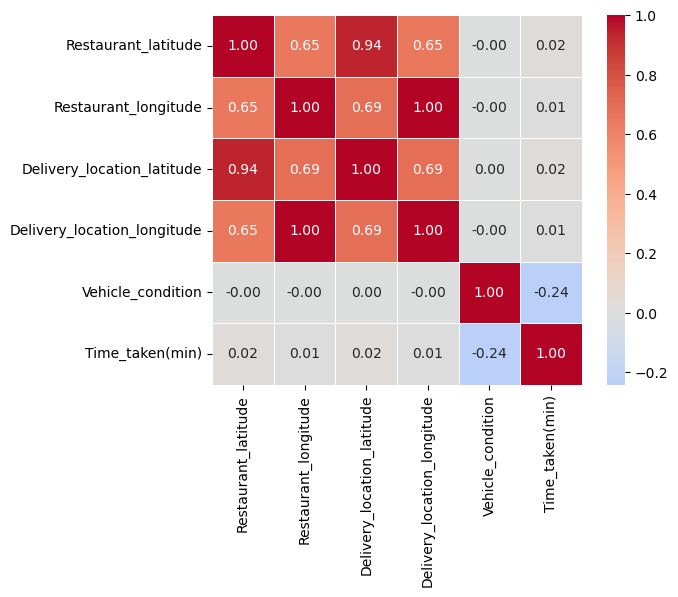

In [14]:
ifdnumeric_cols = ifd.select_dtypes(include=['number']).columns
print(ifdnumeric_cols.tolist())
ifdcorrelation_matrix = ifd[ifdnumeric_cols].corr()
sns.heatmap(
    ifdcorrelation_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=0.5
)
plt.show()

**this is really absurd!! how come there is absolutely no correlation between distance and delivery time?? we need to figure out, there's something wrong with the Distance!!**

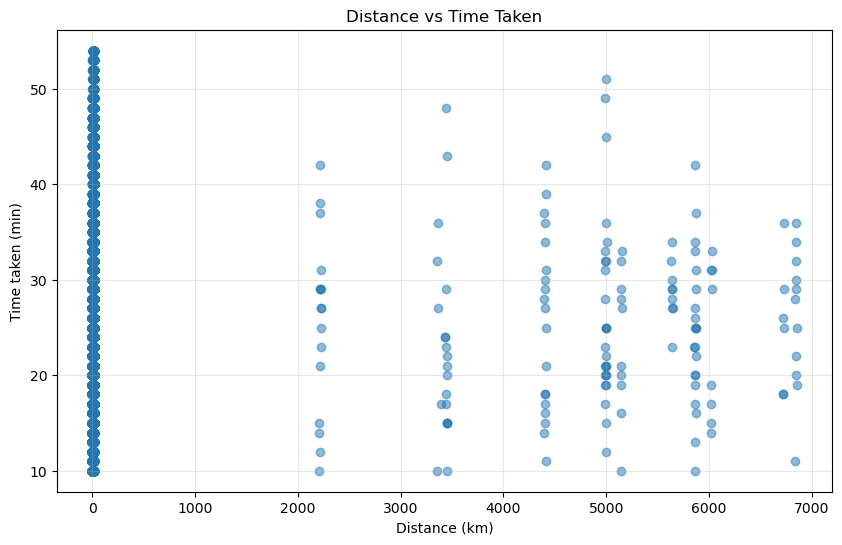

In [96]:
plt.figure(figsize=(10, 6))
plt.scatter(ifd['distance_km'], ifd['Time_taken(min)'], alpha=0.5)
plt.xlabel('Distance (km)')
plt.ylabel('Time taken (min)')
plt.title('Distance vs Time Taken')
plt.grid(True, alpha=0.3)
plt.show()

In [97]:
# 1. 查看Time_taken(min)的分布
print("Time_taken(min) 的值分布:")
print(ifd['Time_taken(min)'].value_counts().head(20))

print("\nTime_taken(min) 的统计:")
print(ifd['Time_taken(min)'].describe())

# 2. 查看异常值的数量
print(f"\n值为0的数量: {(ifd['Time_taken(min)'] == 0).sum()}")
print(f"值 > 100的数量: {(ifd['Time_taken(min)'] > 100).sum()}")
print(f"值 > 1000的数量: {(ifd['Time_taken(min)'] > 1000).sum()}")

Time_taken(min) 的值分布:
Time_taken(min)
26    1814
25    1738
27    1688
28    1679
29    1646
19    1483
18    1441
15    1434
16    1416
23    1395
24    1394
17    1379
20    1370
22    1366
21    1316
33    1086
31    1052
30    1035
34    1002
32     951
Name: count, dtype: int64

Time_taken(min) 的统计:
count    38064.000000
mean        26.576109
std          9.330616
min         10.000000
25%         19.000000
50%         26.000000
75%         33.000000
max         54.000000
Name: Time_taken(min), dtype: float64

值为0的数量: 0
值 > 100的数量: 0
值 > 1000的数量: 0


**delivery time seems to be normal**

**然后展示这些数据，说明问题所在！！**

In [98]:
# 1. 查看distance_km的统计
print("distance_km 的统计:")
print(ifd['distance_km'].describe())

# 2. 查看distance_km的分布
print("\ndistance_km 的值分布:")
print(ifd['distance_km'].value_counts().head(20))

# 3. 检查异常值
print(f"\ndistance = 0 的数量: {(ifd['distance_km'] == 0).sum()}")
print(f"distance > 100 的数量: {(ifd['distance_km'] > 100).sum()}")
print(f"distance > 1000 的数量: {(ifd['distance_km'] > 1000).sum()}")

distance_km 的统计:
count    38064.000000
mean        28.274686
std        309.884069
min          1.463837
25%          4.648990
50%          9.204061
75%         13.660855
max       6852.617172
Name: distance_km, dtype: float64

distance_km 的值分布:
distance_km
13.565054    18
13.660738    18
12.098573    18
16.823882    18
7.756953     18
6.205452     18
6.028642     18
3.059242     17
16.794000    17
20.212465    17
7.746015     17
16.611018    17
13.740932    17
6.198357     17
17.102523    17
10.691001    17
7.670170     17
16.366777    17
6.205664     17
3.068186     17
Name: count, dtype: int64

distance = 0 的数量: 0
distance > 100 的数量: 146
distance > 1000 的数量: 146


In [112]:
print("distance > 100 的记录:")
extreme_dist = ifd[ifd['distance_km'] > 100][['Restaurant_latitude', 'Restaurant_longitude',
                                                 'Delivery_location_latitude', 'Delivery_location_longitude',
                                                 'distance_km']].head(10)
print(extreme_dist)


distance > 100 的记录:
      Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
92             -27.163303             78.057044                   27.233303   
283            -27.165108             78.015053                   27.225108   
289            -18.551440            -73.804855                   18.611440   
583            -12.316967             76.603067                   12.326967   
1059           -26.477750            -80.351569                   26.487750   
1091           -15.546594             73.760431                   15.606594   
1451           -17.459710             78.368855                   17.549710   
1544           -26.914142             75.805704                   27.024142   
1783           -23.230791             77.437020                   23.250791   
1976           -22.539129             88.365507                   22.549129   

      Delivery_location_longitude   distance_km  
92                      78.127044   6019.211231  
283       

**we figure out why!! the latitude become negative value!! no wonder!! I will use all the absolute value and then calculate! Now should be better!**

In [10]:
ifd_fixed = ifd.copy()
ifd_fixed['Restaurant_latitude'] = ifd_fixed['Restaurant_latitude'].abs()
ifd_fixed['Restaurant_longitude'] = ifd_fixed['Restaurant_longitude'].abs()
ifd_fixed['Delivery_location_latitude'] = ifd_fixed['Delivery_location_latitude'].abs()
ifd_fixed['Delivery_location_longitude'] = ifd_fixed['Delivery_location_longitude'].abs()

# recalculate the distance 
from geopy.distance import geodesic

def calculate_distance(row):
    restaurant = (row['Restaurant_latitude'], row['Restaurant_longitude'])
    delivery = (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
    return geodesic(restaurant, delivery).kilometers

ifd_fixed['distance_km'] = ifd_fixed.apply(calculate_distance, axis=1)

**最后说明怎么解决的（取绝对值），然后展示下面两张图！！**

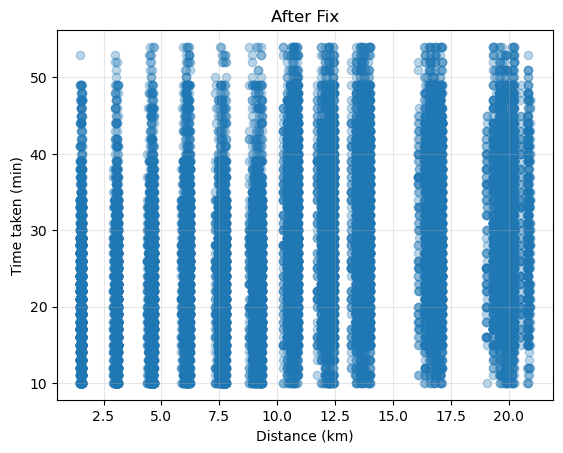

In [115]:
plt.scatter(ifd_fixed['distance_km'], ifd_fixed['Time_taken(min)'], alpha=0.3)
plt.xlabel('Distance (km)')
plt.ylabel('Time taken (min)')
plt.title('After Fix')
plt.grid(True, alpha=0.3)
plt.show()

## EDA And Data Visualization

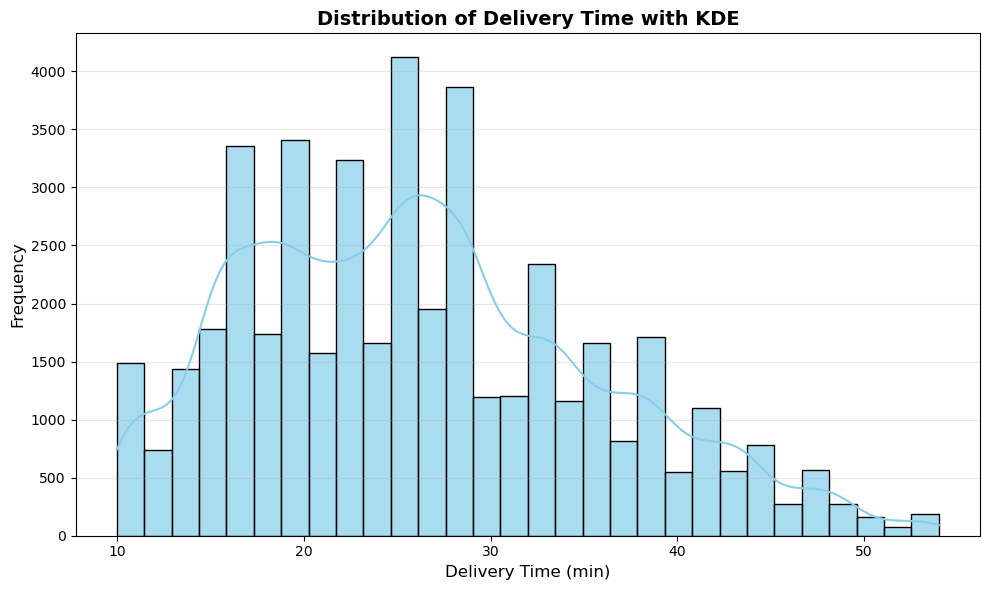

In [44]:
plt.figure(figsize=(10, 6))

sns.histplot(data=ifd, x='Time_taken(min)', kde=True, bins=30, 
             color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Distribution of Delivery Time with KDE', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Time (min)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

['Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'Time_taken(min)', 'distance_km']


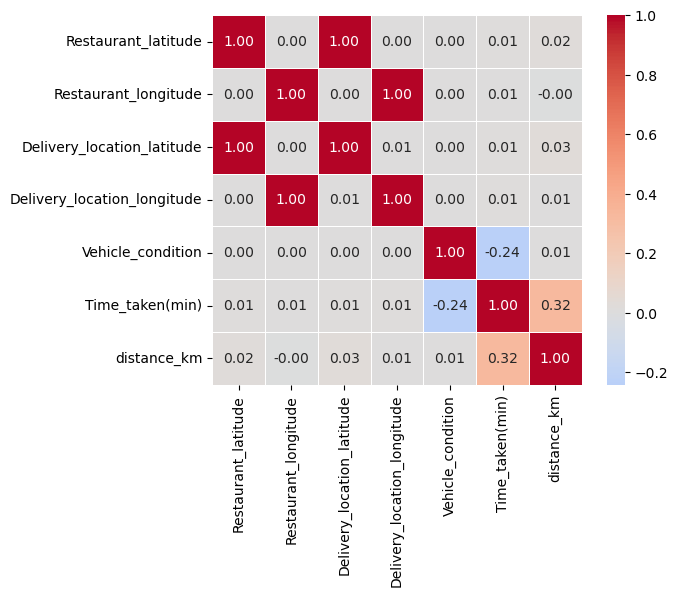

In [107]:
ifdnumeric_cols_fixed = ifd_fixed.select_dtypes(include=['number']).columns
print(ifdnumeric_cols_fixed.tolist())
ifdcorrelation_matrix_fixed = ifd_fixed[ifdnumeric_cols_fixed].corr()
sns.heatmap(
    ifdcorrelation_matrix_fixed,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    square=True,
    linewidths=0.5
)
plt.show()

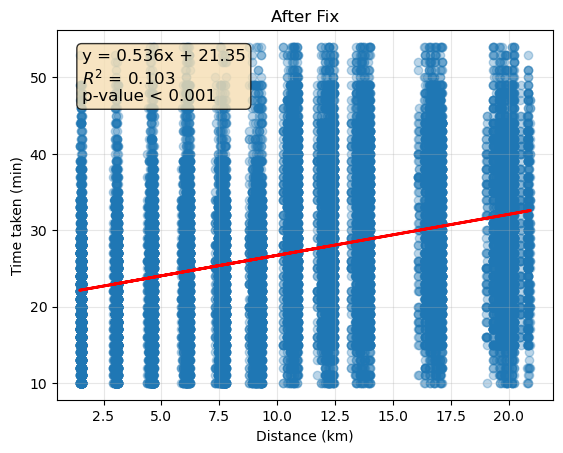

In [121]:
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(ifd_fixed['distance_km'], 
                                                                 ifd_fixed['Time_taken(min)'])
line = slope * ifd_fixed['distance_km'] + intercept
plt.plot(ifd_fixed['distance_km'], line, 'r-', linewidth=2, label=f'y={slope:.2f}x+{intercept:.2f}')
plt.scatter(ifd_fixed['distance_km'], ifd_fixed['Time_taken(min)'], alpha=0.3)
plt.xlabel('Distance (km)')
plt.ylabel('Time taken (min)')
plt.title('After Fix')
plt.grid(True, alpha=0.3)
textstr = f'y = {slope:.3f}x + {intercept:.2f}\n$R^2$ = {r_value**2:.3f}\np-value < 0.001'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=props)

plt.show()

**R Squared is only 0.103, meaning that only 10.3% of all the variance can be explained by this model. This is too bad, we need to find new methods!**

Now we will see the combination effect of both Distance and Vehicle condition on Time taken.

C:\Users\USER\AppData\Local\Temp\ipykernel_16360\2424666794.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(grouped_data, labels=labels, patch_artist=True)


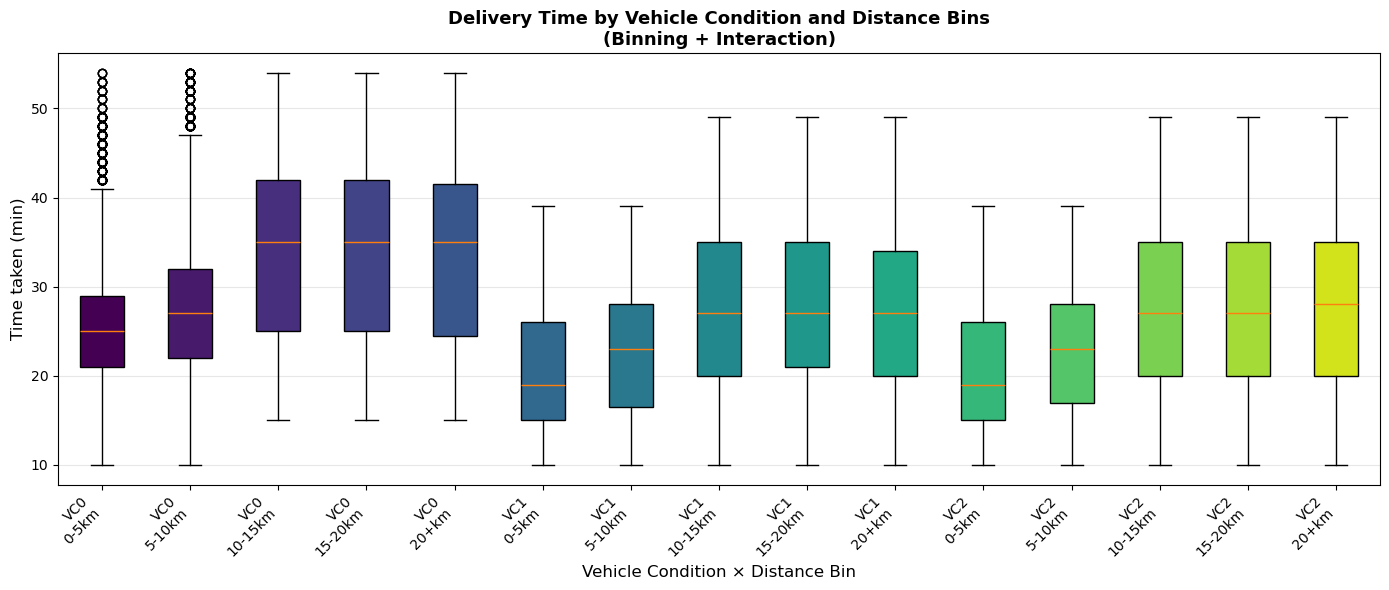


各组合的平均配送时间:
                                     mean  count
Vehicle_condition distance_bin                  
0                 0-5km         25.533252   4075
                  5-10km        28.024919   4013
                  10-15km       33.933793   4063
                  15-20km       34.014104   2127
                  20+km         33.816208    691
1                 0-5km         20.407882   4060
                  5-10km        22.522057   4103
                  10-15km       27.795796   3996
                  15-20km       27.929735   2149
                  20+km         27.486994    692
2                 0-5km         20.440614   3974
                  5-10km        22.580621   4025
                  10-15km       27.810565   4070
                  15-20km       27.708220   2214
                  20+km         28.092414    725


C:\Users\USER\AppData\Local\Temp\ipykernel_16360\2424666794.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = ifd_fixed.groupby(['Vehicle_condition', 'distance_bin'])['Time_taken(min)'].agg(['mean', 'count'])


In [61]:
# 将距离分箱
ifd_fixed['distance_bin'] = pd.cut(ifd_fixed['distance_km'], 
                                    bins=[0, 5, 10, 15, 20, 100],
                                    labels=['0-5km', '5-10km', '10-15km', '15-20km', '20+km'])

# 创建组合特征
ifd_fixed['vehicle_distance_group'] = (ifd_fixed['Vehicle_condition'].astype(str) + '_' + 
                                        ifd_fixed['distance_bin'].astype(str))

# 可视化分组效果
plt.figure(figsize=(14, 6))

# 箱线图显示不同组合的配送时间分布
grouped_data = []
labels = []
for vc in sorted(ifd_fixed['Vehicle_condition'].unique()):
    for dist_bin in ['0-5km', '5-10km', '10-15km', '15-20km', '20+km']:
        subset = ifd_fixed[(ifd_fixed['Vehicle_condition'] == vc) & 
                          (ifd_fixed['distance_bin'] == dist_bin)]
        if len(subset) > 10:
            grouped_data.append(subset['Time_taken(min)'])
            labels.append(f'VC{int(vc)}\n{dist_bin}')

bp = plt.boxplot(grouped_data, labels=labels, patch_artist=True)
for i, box in enumerate(bp['boxes']):
    box.set_facecolor(plt.cm.viridis(i / len(bp['boxes'])))

plt.xlabel('Vehicle Condition × Distance Bin', fontsize=12)
plt.ylabel('Time taken (min)', fontsize=12)
plt.title('Delivery Time by Vehicle Condition and Distance Bins\n(Binning + Interaction)', 
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 计算每组的平均配送时间
group_stats = ifd_fixed.groupby(['Vehicle_condition', 'distance_bin'])['Time_taken(min)'].agg(['mean', 'count'])
print("\n各组合的平均配送时间:")
print(group_stats)

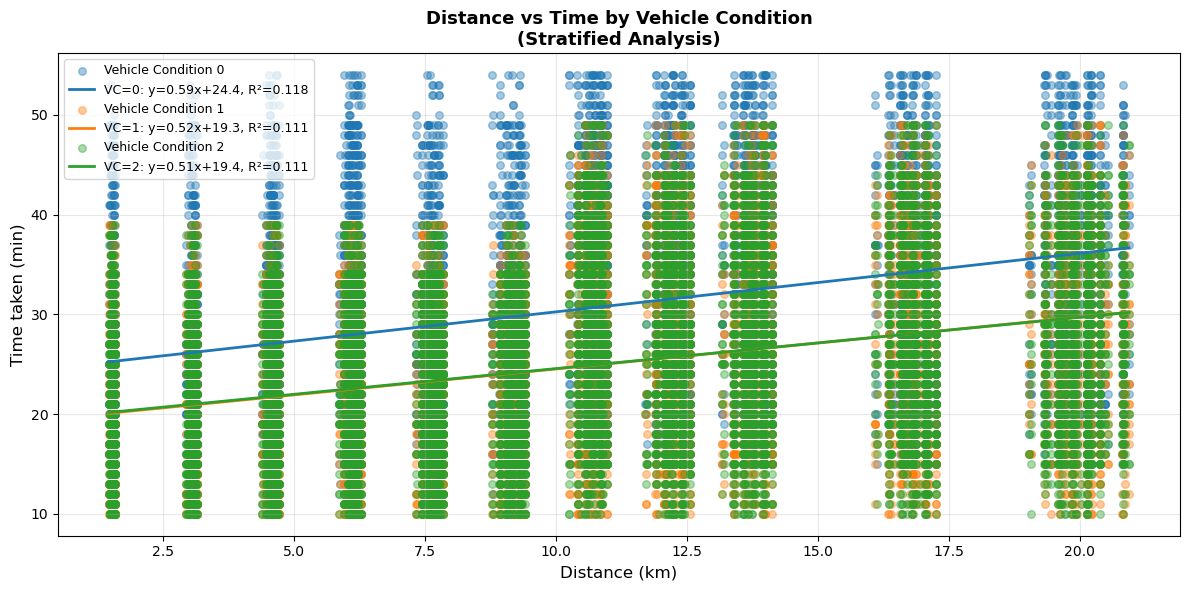

In [60]:
fig, ax = plt.subplots(figsize=(12, 6))

for condition in sorted(ifd_fixed['Vehicle_condition'].unique()):
    subset = ifd_fixed[ifd_fixed['Vehicle_condition'] == condition]
    ax.scatter(subset['distance_km'], subset['Time_taken(min)'], 
               alpha=0.4, label=f'Vehicle Condition {int(condition)}', s=30)
    
    # Draw a regression line for each car condition (feature):
    if len(subset) > 10:
        slope, intercept, r_val, _, _ = stats.linregress(subset['distance_km'], subset['Time_taken(min)'])
        line_x = np.array([subset['distance_km'].min(), subset['distance_km'].max()])
        line_y = slope * line_x + intercept
        ax.plot(line_x, line_y, linewidth=2, 
                label=f'VC={int(condition)}: y={slope:.2f}x+{intercept:.1f}, R²={r_val**2:.3f}')

ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Time taken (min)', fontsize=12)
ax.set_title('Distance vs Time by Vehicle Condition\n(Stratified Analysis)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Not much difference, only about 11% can be explained by the variance. Not enough to explain. 

**I would like to see the effect of type of vehicles, as well as weather conditions, and how it plays differently to the delivery time.**

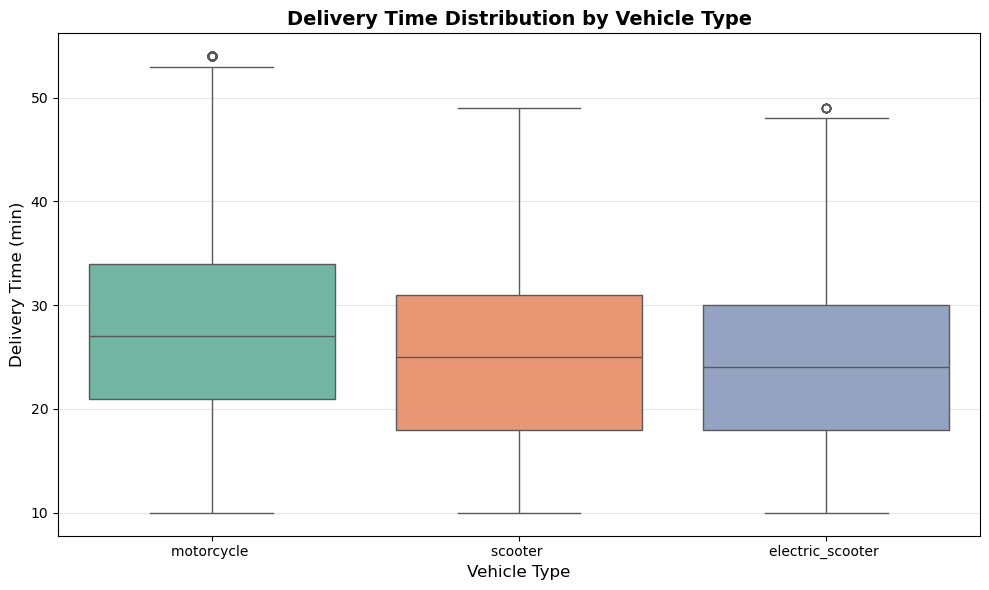

In [15]:
plt.figure(figsize=(10, 6))
order = ifd.groupby('Type_of_vehicle')['Time_taken(min)'].median().sort_values(ascending=False).index
sns.boxplot(data=ifd, x='Type_of_vehicle', y='Time_taken(min)', order=order, 
            hue='Type_of_vehicle', palette='Set2', legend=False)
plt.title('Delivery Time Distribution by Vehicle Type', fontsize=14, fontweight='bold')
plt.xlabel('Vehicle Type', fontsize=12)
plt.ylabel('Delivery Time (min)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
from scipy import stats
groups = [group['Time_taken(min)'].values for name, group in ifd.groupby('Type_of_vehicle')]

# ANOVA
f_stat, p_value = stats.f_oneway(*groups)
print(f"F stats: {f_stat:.4f}")
print(f"p value: {p_value:.4e}")

F stats: 524.8602
p value: 1.3894e-225


p value is close to 0!! means it is absolutely relavant to our analysis (p<.05, means it is significant).

In [19]:
grand_mean = ifd['Time_taken(min)'].mean()
ss_between = sum([len(group) * (group['Time_taken(min)'].mean() - grand_mean)**2 
                  for name, group in ifd.groupby('Type_of_vehicle')])
ss_total = sum((ifd['Time_taken(min)'] - grand_mean)**2)
eta_squared = ss_between / ss_total

print(f"\nEta-squared (η²): {eta_squared:.4f}")
print(f"Explain: Type_of_vehicle can explain Time_taken(min) standard deviation's {eta_squared*100:.2f}%")



Eta-squared (η²): 0.0268
Explain: Type_of_vehicle can explain Time_taken(min) standard deviation's 2.68%


However, it only explains about 2.7% of all the changes! 

Why this happens?

1. HUGE sample size (n = 45,593)
   → Even tiny differences become "statistically significant" (so many items are different)

2. Real-world difference is small:
   • Fastest vehicle: 24.5 min (scooter)
   • Slowest vehicle: 27.6 min (motorcycle)
   • Difference: 3.1 min (only 11%)

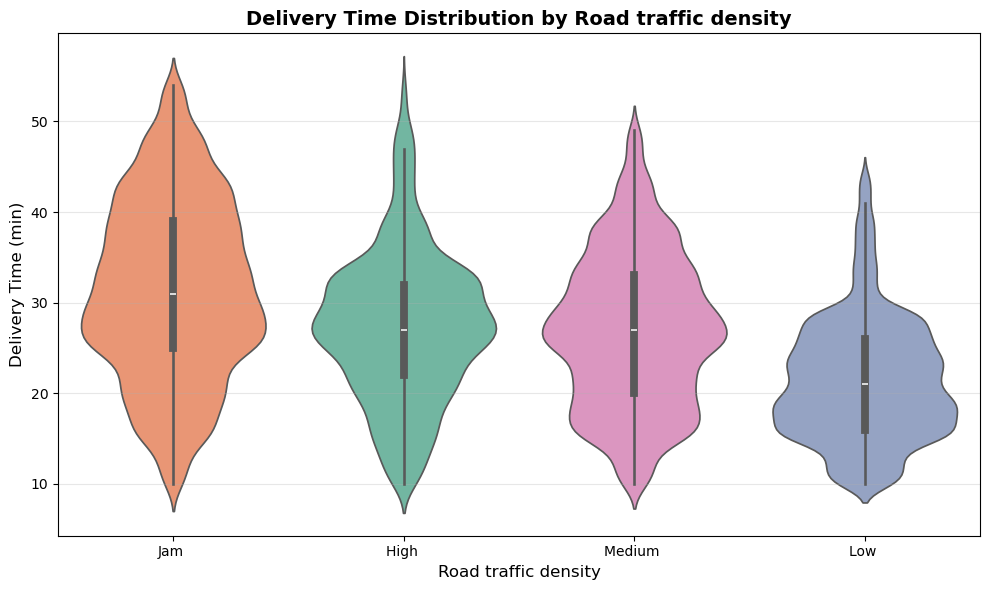

In [21]:
plt.figure(figsize=(10, 6))
order = ifd.groupby('Road_traffic_density')['Time_taken(min)'].median().sort_values(ascending=False).index
sns.violinplot(data=ifd, x='Road_traffic_density', y='Time_taken(min)', order=order, 
            hue='Road_traffic_density', palette='Set2', legend=False)
plt.title('Delivery Time Distribution by Road traffic density', fontsize=14, fontweight='bold')
plt.xlabel('Road traffic density', fontsize=12)
plt.ylabel('Delivery Time (min)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
groups = [group['Time_taken(min)'].values for name, group in ifd.groupby('Road_traffic_density')]

# ANOVA
f_stat, p_value = stats.f_oneway(*groups)
print(f"F stats: {f_stat:.4f}")
print(f"p value: {p_value:.4e}")

F stats: 2895.9441
p value: 0.0000e+00


In [24]:
grand_mean2 = ifd['Time_taken(min)'].mean()
ss_between2 = sum([len(group) * (group['Time_taken(min)'].mean() - grand_mean2)**2 
                  for name, group in ifd.groupby('Road_traffic_density')])
ss_total2 = sum((ifd['Time_taken(min)'] - grand_mean2)**2)
eta_squared2 = ss_between2 / ss_total2

print(f"\nEta-squared (η²): {eta_squared2:.4f}")
print(f"Explain: Road_traffic_density can explain Time_taken(min) standard deviation's {eta_squared2*100:.2f}%")



Eta-squared (η²): 0.1858
Explain: Road_traffic_density can explain Time_taken(min) standard deviation's 18.58%


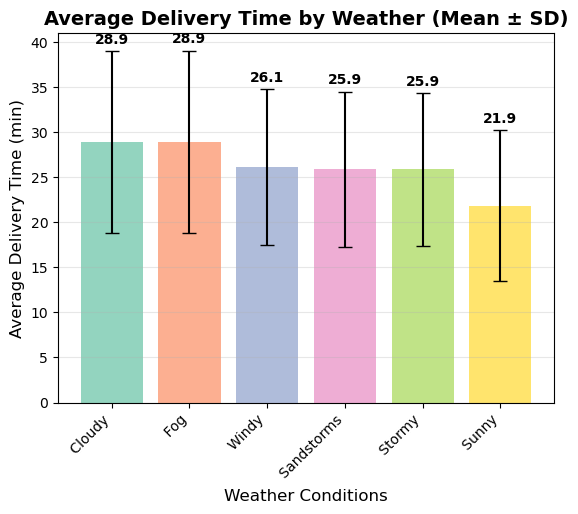

In [40]:
ifd['Weather'] = ifd['Weather'].replace([' NaN', 'nan', 'Nan', 'NaN', 'NaN '], np.nan)
ifd = ifd.dropna(subset=['Weather'])
order = ifd.groupby('Weather')['Time_taken(min)'].mean().sort_values(ascending=False).index
means = ifd.groupby('Weather')['Time_taken(min)'].mean().reindex(order)
stds = ifd.groupby('Weather')['Time_taken(min)'].std().reindex(order)
x_pos = np.arange(len(order))

bars = plt.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, 
               color=sns.color_palette('Set2', len(order)))
plt.xticks(x_pos, order, rotation=45, ha='right')
plt.title('Average Delivery Time by Weather (Mean ± SD)', 
              fontsize=14, fontweight='bold')
plt.xlabel('Weather Conditions', fontsize=12)
plt.ylabel('Average Delivery Time (min)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# adding values
for i, (mean, std) in enumerate(zip(means, stds)):
    plt.text(i, mean + std + 0.5, f'{mean:.1f}', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.show()

In [42]:
groups = [group['Time_taken(min)'].values for name, group in ifd.groupby('Weather')]

# ANOVA
f_stat, p_value = stats.f_oneway(*groups)
print(f"F stats: {f_stat:.4f}")
print(f"p value: {p_value:.4e}")

F stats: 608.2196
p value: 0.0000e+00


In [43]:
grand_mean3 = ifd['Time_taken(min)'].mean()
ss_between3 = sum([len(group) * (group['Time_taken(min)'].mean() - grand_mean2)**2 
                  for name, group in ifd.groupby('Weather')])
ss_total3 = sum((ifd['Time_taken(min)'] - grand_mean2)**2)
eta_squared3 = ss_between3 / ss_total3

print(f"\nEta-squared (η²): {eta_squared3:.4f}")
print(f"Explain: Weather can explain Time_taken(min) standard deviation's {eta_squared3*100:.2f}%")


Eta-squared (η²): 0.0642
Explain: Weather can explain Time_taken(min) standard deviation's 6.42%


**Now!! Feature engineering. Since we realize that only the vehicle condition and distance matters to food delivery time, we will use 2 different ways of feature engineering to test it out, to see what relationship it is**

## Data Processing and Feature Engineering

Polynomial Features:
0: distance_km
1: Vehicle_condition
2: distance_km^2
3: distance_km Vehicle_condition
4: Vehicle_condition^2

The Correlation between each Polynomial Feature and Time Taken:
Time_taken(min)                  1.000000
distance_km                      0.321532
distance_km^2                    0.287761
distance_km Vehicle_condition   -0.020135
Vehicle_condition^2             -0.194084
Vehicle_condition               -0.244127
Name: Time_taken(min), dtype: float64

Model Comparison:
Simple Linear Regression R²: 0.1642
Polynomial Regression R²: 0.1939
Improvement: 0.0296


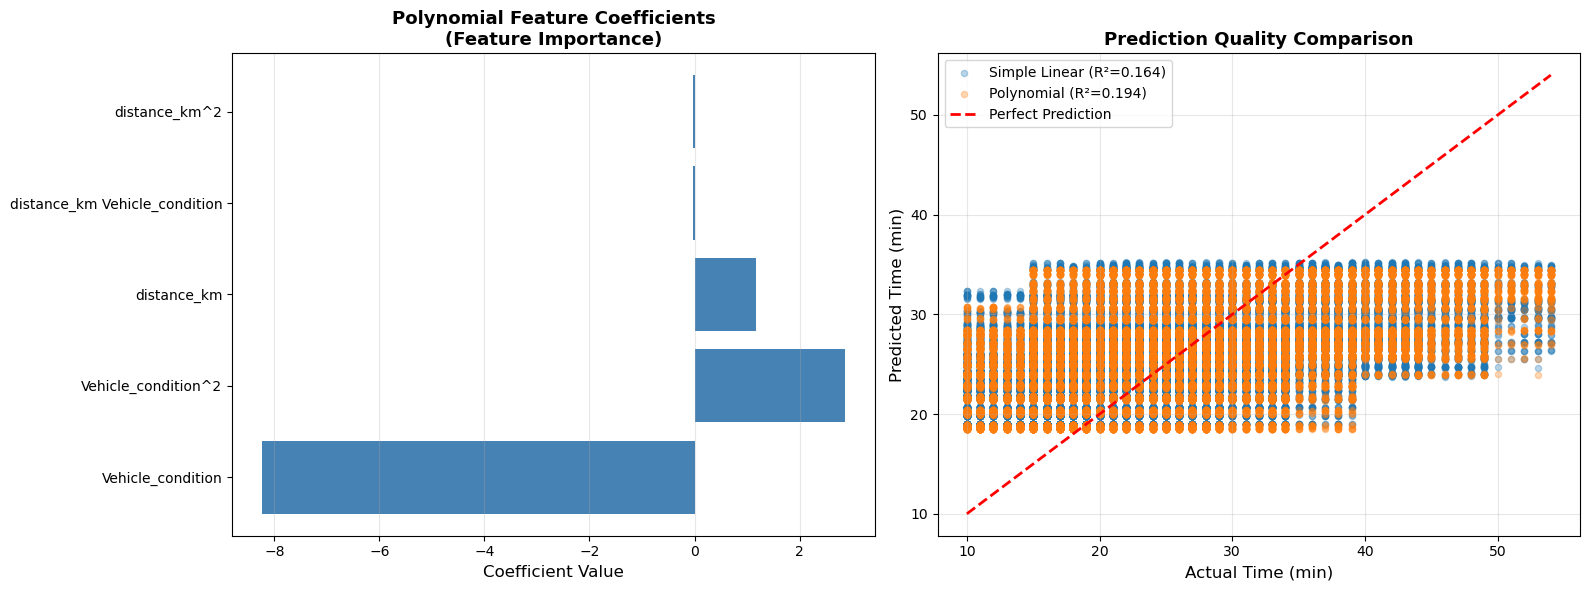

In [62]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# create a polynomial feature (2 polynomials)
poly = PolynomialFeatures(degree=2, include_bias=False)
X = ifd_fixed[['distance_km', 'Vehicle_condition']].values
X_poly = poly.fit_transform(X)

# check the names 
feature_names = poly.get_feature_names_out(['distance_km', 'Vehicle_condition'])
print("Polynomial Features:")
for i, name in enumerate(feature_names):
    print(f"{i}: {name}")

# Create DataFrame including all polynomial features
poly_df = pd.DataFrame(X_poly, columns=feature_names, index=ifd_fixed.index)
poly_df['Time_taken(min)'] = ifd_fixed['Time_taken(min)'].values

# Calculate all the correlation between these polynomials
print("\nThe Correlation between each Polynomial Feature and Time Taken:")
correlations = poly_df.corr()['Time_taken(min)'].sort_values(ascending=False)
print(correlations)

# Polynomial Regression
y = ifd_fixed['Time_taken(min)'].values
model_poly = LinearRegression()
model_poly.fit(X_poly, y)
y_pred_poly = model_poly.predict(X_poly)
r2_poly = r2_score(y, y_pred_poly)

# Compare with simple linear regression
model_simple = LinearRegression()
model_simple.fit(X, y)
y_pred_simple = model_simple.predict(X)
r2_simple = r2_score(y, y_pred_simple)

print(f"\nModel Comparison:")
print(f"Simple Linear Regression R²: {r2_simple:.4f}")
print(f"Polynomial Regression R²: {r2_poly:.4f}")
print(f"Improvement: {(r2_poly - r2_simple):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: the importance of the polynomial（Regression Coefficient）
coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model_poly.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

axes[0].barh(coefficients['Feature'], coefficients['Coefficient'], color='steelblue')
axes[0].set_xlabel('Coefficient Value', fontsize=12)
axes[0].set_title('Polynomial Feature Coefficients\n(Feature Importance)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Right: Prediction
axes[1].scatter(y, y_pred_simple, alpha=0.3, label=f'Simple Linear (R²={r2_simple:.3f})', s=20)
axes[1].scatter(y, y_pred_poly, alpha=0.3, label=f'Polynomial (R²={r2_poly:.3f})', s=20)
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Time (min)', fontsize=12)
axes[1].set_ylabel('Predicted Time (min)', fontsize=12)
axes[1].set_title('Prediction Quality Comparison', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This means: among all the coefficient, the most important is the Vehicle Condition. However, Even after this Polynomial Regression, the R² is still only less than 20%. Means the importance of weather and traffic is very high! 

In [97]:
ifd_fixed = pd.read_csv('India_Food_Delivery.csv') 

In [98]:
print("Original lane:", len(ifd_fixed))
print("\nRoad_traffic_density only values:")
print(ifd_fixed['Road_traffic_density'].unique())
print("\nWeather only values:")
print(ifd_fixed['Weather'].unique())

Original lane: 45593

Road_traffic_density only values:
['High ' 'Jam ' 'Low ' 'Medium ' 'NaN ']

Weather only values:
[' Sunny' ' Stormy' ' Sandstorms' ' Cloudy' ' Fog' ' Windy' ' NaN']


In [103]:
ifd_fixed['Road_traffic_density'] = ifd_fixed['Road_traffic_density'].str.strip().replace('NaN', np.nan)
ifd_fixed['Weather'] = ifd_fixed['Weather'].str.strip().replace('NaN', np.nan)
ifd_fixed = ifd_fixed.dropna(subset=['Road_traffic_density', 'Weather', 'Time_taken(min)'])

In [104]:
print("Original lane:", len(ifd_fixed))
print("\nRoad_traffic_density only values:")
print(ifd_fixed['Road_traffic_density'].unique())
print("\nWeather only values:")
print(ifd_fixed['Weather'].unique())

Original lane: 44977

Road_traffic_density only values:
['High' 'Jam' 'Low' 'Medium']

Weather only values:
['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy']



所有缩放方法的回归结果对比:
  Method       R²     RMSE  Dist_Coef  Vehicle_Coef  Interaction_Coef
Original 0.163302 8.534713   0.569985     -2.491274         -0.030505
 Z-score 0.163302 8.534713   3.018053     -2.279928         -0.139495
 Min-Max 0.163302 8.534713  11.102779     -5.071858         -1.188436
  Robust 0.163302 8.534713   4.861414     -5.544067         -0.549788


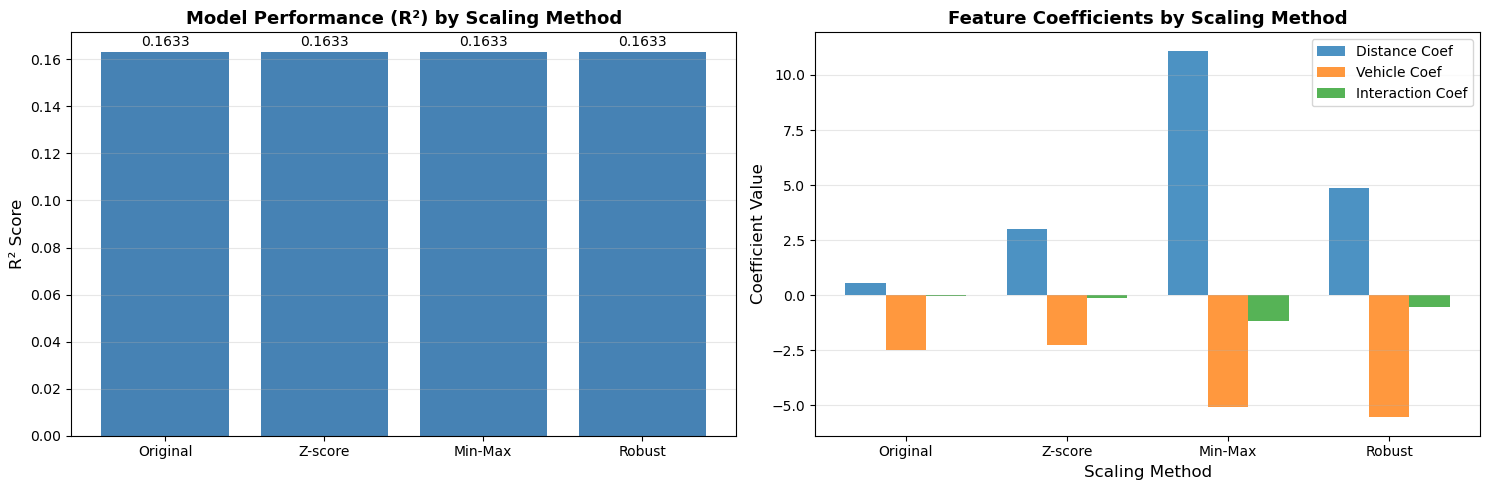

In [129]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

# 准备数据
scaling_results = []

methods = {
    'Original': ['distance_km', 'Vehicle_condition'],
    'Z-score': ['distance_km_zscore', 'vehicle_condition_zscore'],
    'Min-Max': ['distance_km_normalized', 'vehicle_condition_normalized'],
    'Robust': ['distance_km_robust', 'vehicle_condition_robust']
}

y = ifd_fixed['Time_taken(min)']

for method_name, features in methods.items():
    # 准备特征（包含交互项）
    X = ifd_fixed[features].copy()
    X['interaction'] = X[features[0]] * X[features[1]]
    
    # 训练模型
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # 计算指标
    r2 = r2_score(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    scaling_results.append({
        'Method': method_name,
        'R²': r2,
        'RMSE': rmse,
        'Dist_Coef': model.coef_[0],
        'Vehicle_Coef': model.coef_[1],
        'Interaction_Coef': model.coef_[2]
    })

results_df = pd.DataFrame(scaling_results)
print("\n所有缩放方法的回归结果对比:")
print(results_df.to_string(index=False))

# 可视化结果对比
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# R²对比
axes[0].bar(results_df['Method'], results_df['R²'], color='steelblue')
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Model Performance (R²) by Scaling Method', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(results_df['R²']):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

# 系数对比
x = np.arange(len(results_df))
width = 0.25
axes[1].bar(x - width, results_df['Dist_Coef'], width, label='Distance Coef', alpha=0.8)
axes[1].bar(x, results_df['Vehicle_Coef'], width, label='Vehicle Coef', alpha=0.8)
axes[1].bar(x + width, results_df['Interaction_Coef'], width, label='Interaction Coef', alpha=0.8)
axes[1].set_xlabel('Scaling Method', fontsize=12)
axes[1].set_ylabel('Coefficient Value', fontsize=12)
axes[1].set_title('Feature Coefficients by Scaling Method', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Method'])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Step 1: Creating feature scaling...
✓ Feature scaling completed!
New columns: ['distance_km_zscore', 'vehicle_condition_zscore', 'distance_km_normalized', 'vehicle_condition_normalized', 'distance_km_robust', 'vehicle_condition_robust']

Step 2: Preparing data...
Number of features: 3
Number of samples: 41368

Training set: 33094 samples
Test set: 8274 samples

Training: Linear Regression
Train R²:          0.1610
Test R²:           0.1728
Test RMSE:         8.5201 minutes
Test MAE:          6.9762 minutes
Cross-val R²:      0.1606 (±0.0109)
Overfitting Gap:   -0.0118

Training: Random Forest
Train R²:          0.2507
Test R²:           0.2149
Test RMSE:         8.3002 minutes
Test MAE:          6.8279 minutes
Cross-val R²:      0.2044 (±0.0101)
Overfitting Gap:   0.0357

Training: Gradient Boosting
Train R²:          0.2379
Test R²:           0.2170
Test RMSE:         8.2895 minutes
Test MAE:          6.8203 minutes
Cross-val R²:      0.2072 (±0.0094)
Overfitting Gap:   0.0209


📊 Mod

C:\Users\USER\AppData\Local\Temp\ipykernel_22424\823197024.py:194: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(results_df['Model'], rotation=20, ha='right')


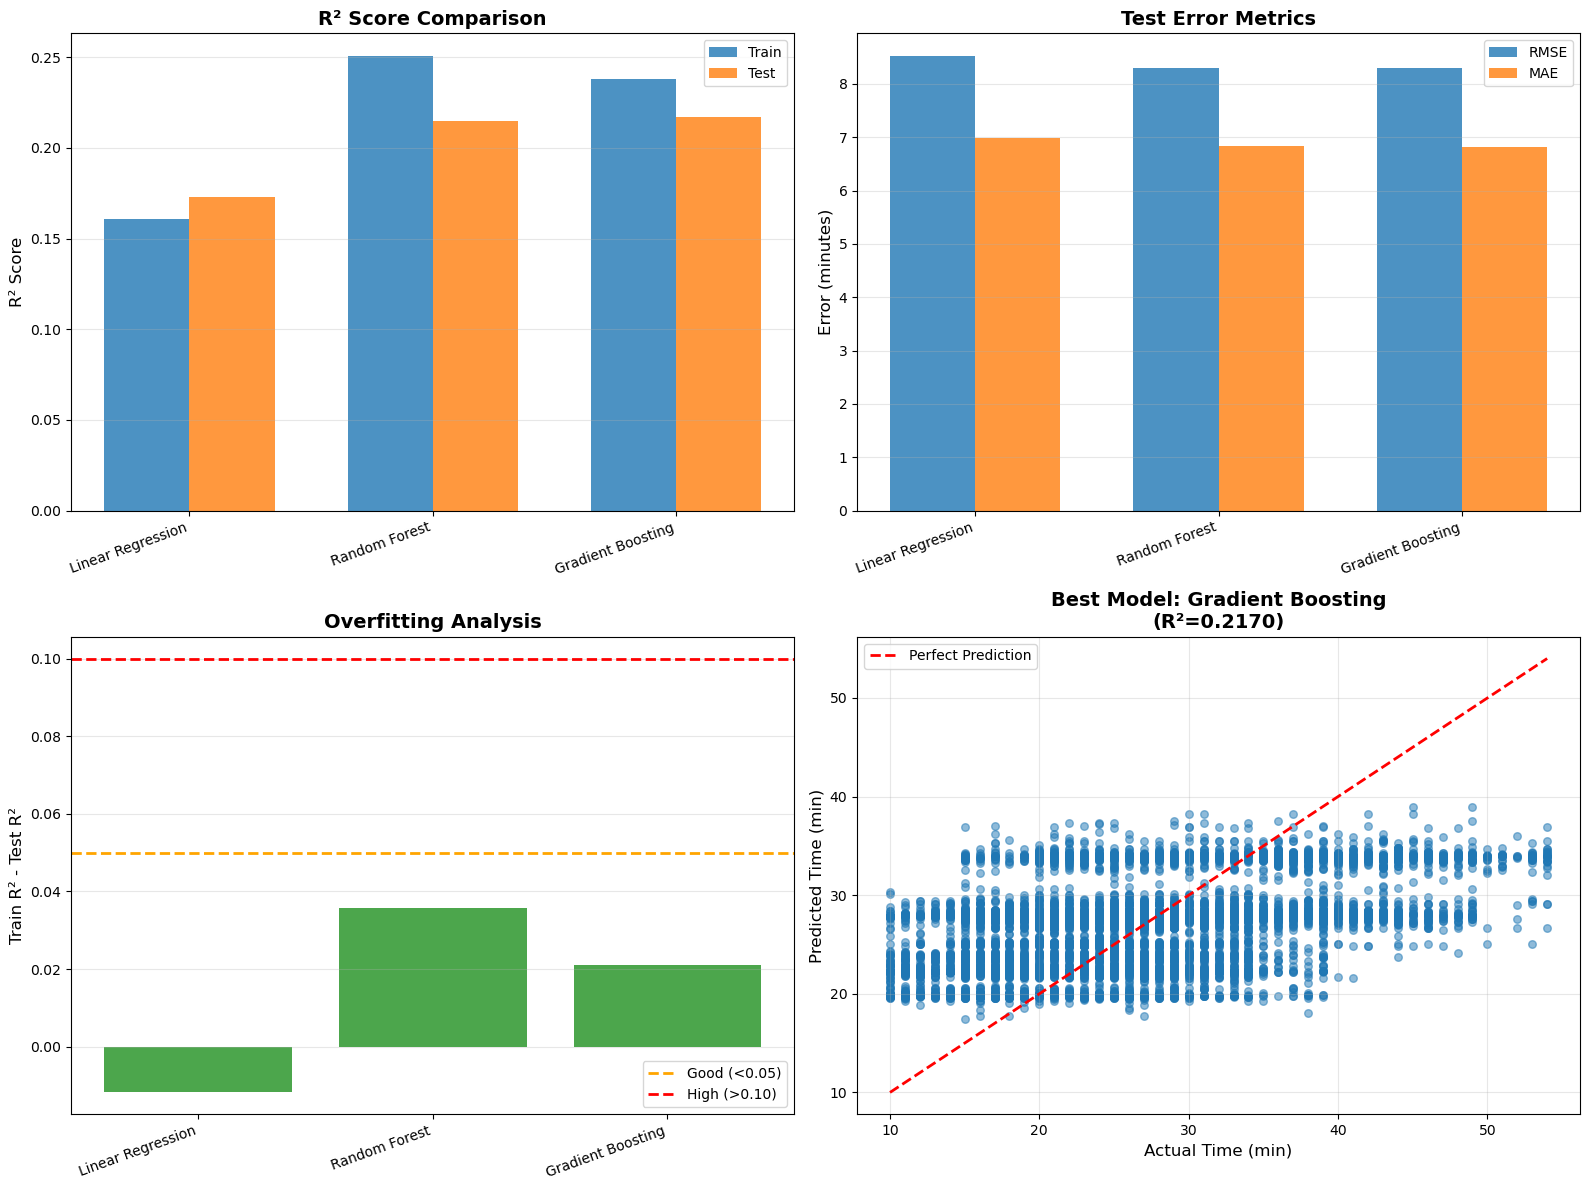


🔍 Feature Importance Analysis:

Random Forest:
  distance_km_zscore            : 0.5961 █████████████████████████████
  interaction                   : 0.3211 ████████████████
  vehicle_condition_zscore      : 0.0828 ████

Gradient Boosting:
  distance_km_zscore            : 0.6014 ██████████████████████████████
  interaction                   : 0.2970 ██████████████
  vehicle_condition_zscore      : 0.1017 █████


In [11]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================
# Step 1: Create scaled features (if not already done)
# ============================================
print("Step 1: Creating feature scaling...")

# Assuming your original column names are 'distance_km' and 'Vehicle_condition'
# Modify according to your actual situation
original_features = ['distance_km', 'Vehicle_condition']

# Z-score standardization
scaler_zscore = StandardScaler()
ifd_fixed[['distance_km_zscore', 'vehicle_condition_zscore']] = scaler_zscore.fit_transform(
    ifd_fixed[original_features]
)

# Min-Max normalization (optional)
scaler_minmax = MinMaxScaler()
ifd_fixed[['distance_km_normalized', 'vehicle_condition_normalized']] = scaler_minmax.fit_transform(
    ifd_fixed[original_features]
)

# Robust scaling (optional)
scaler_robust = RobustScaler()
ifd_fixed[['distance_km_robust', 'vehicle_condition_robust']] = scaler_robust.fit_transform(
    ifd_fixed[original_features]
)

print("✓ Feature scaling completed!")
print(f"New columns: {[col for col in ifd_fixed.columns if 'zscore' in col or 'normalized' in col or 'robust' in col]}\n")

# ============================================
# Step 2: Prepare data
# ============================================
print("Step 2: Preparing data...")

# Use Z-score scaled features
feature_cols = ['distance_km_zscore', 'vehicle_condition_zscore']
X = ifd_fixed[feature_cols].copy()
X['interaction'] = X[feature_cols[0]] * X[feature_cols[1]]
y = ifd_fixed['Time_taken(min)']

print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}\n")

# ============================================
# Step 3: Split train and test sets
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples\n")

# ============================================
# Step 4: Define models
# ============================================
models = {
    'Linear Regression': LinearRegression(),
    
    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    )
}

# ============================================
# Step 5: Training and evaluation
# ============================================
results = []

for model_name, model in models.items():
    print(f"{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Training set metrics
    train_r2 = r2_score(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    
    # Test set metrics
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    # Print results
    print(f"Train R²:          {train_r2:.4f}")
    print(f"Test R²:           {test_r2:.4f}")
    print(f"Test RMSE:         {test_rmse:.4f} minutes")
    print(f"Test MAE:          {test_mae:.4f} minutes")
    print(f"Cross-val R²:      {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print(f"Overfitting Gap:   {train_r2 - test_r2:.4f}")
    print()
    
    results.append({
        'Model': model_name,
        'Train_R²': train_r2,
        'Test_R²': test_r2,
        'Test_RMSE': test_rmse,
        'Test_MAE': test_mae,
        'CV_R²': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Overfit': train_r2 - test_r2
    })

# ============================================
# Step 6: Results summary
# ============================================
results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("📊 Model Performance Comparison:")
print("="*80)
print(results_df.to_string(index=False))
print("\n")

# Find best model
best_idx = results_df['Test_R²'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
print(f"🏆 Best Model: {best_model_name}")
print(f"   Test R²: {results_df.loc[best_idx, 'Test_R²']:.4f}")
print(f"   Test RMSE: {results_df.loc[best_idx, 'Test_RMSE']:.4f} minutes")

# ============================================
# Step 7: Visualization
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: R² comparison
ax1 = axes[0, 0]
x = np.arange(len(results_df))
width = 0.35
ax1.bar(x - width/2, results_df['Train_R²'], width, label='Train', alpha=0.8)
ax1.bar(x + width/2, results_df['Test_R²'], width, label='Test', alpha=0.8)
ax1.set_ylabel('R² Score', fontsize=12)
ax1.set_title('R² Score Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Error comparison
ax2 = axes[0, 1]
ax2.bar(x - width/2, results_df['Test_RMSE'], width, label='RMSE', alpha=0.8)
ax2.bar(x + width/2, results_df['Test_MAE'], width, label='MAE', alpha=0.8)
ax2.set_ylabel('Error (minutes)', fontsize=12)
ax2.set_title('Test Error Metrics', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Overfitting analysis
ax3 = axes[1, 0]
colors = ['green' if x < 0.05 else 'orange' if x < 0.1 else 'red' 
          for x in results_df['Overfit']]
ax3.bar(results_df['Model'], results_df['Overfit'], color=colors, alpha=0.7)
ax3.axhline(y=0.05, color='orange', linestyle='--', linewidth=2, label='Good (<0.05)')
ax3.axhline(y=0.1, color='red', linestyle='--', linewidth=2, label='High (>0.10)')
ax3.set_ylabel('Train R² - Test R²', fontsize=12)
ax3.set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
ax3.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Best model prediction performance
ax4 = axes[1, 1]
best_model = models[best_model_name]
y_pred = best_model.predict(X_test)
ax4.scatter(y_test, y_pred, alpha=0.5, s=30)
ax4.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax4.set_xlabel('Actual Time (min)', fontsize=12)
ax4.set_ylabel('Predicted Time (min)', fontsize=12)
ax4.set_title(f'Best Model: {best_model_name}\n(R²={results_df.loc[best_idx, "Test_R²"]:.4f})', 
              fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# Step 8: Feature importance (tree models only)
# ============================================
print("\n" + "="*80)
print("🔍 Feature Importance Analysis:")
print("="*80)

for name in ['Random Forest', 'Gradient Boosting']:
    model = models[name]
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_names = X.columns
        
        print(f"\n{name}:")
        for feat, imp in sorted(zip(feature_names, importances), 
                                key=lambda x: x[1], reverse=True):
            print(f"  {feat:30s}: {imp:.4f} {'█' * int(imp * 50)}")